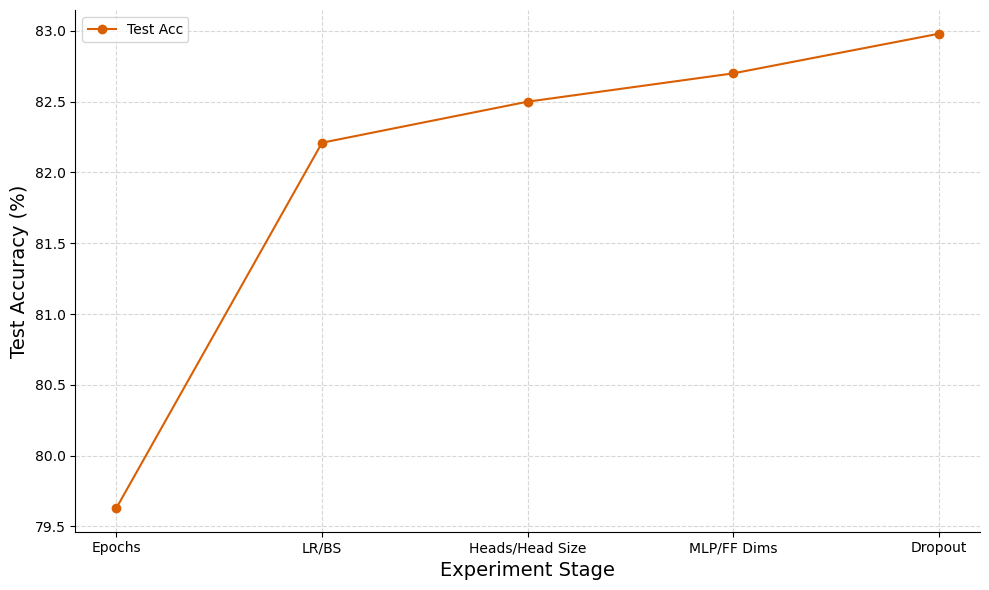

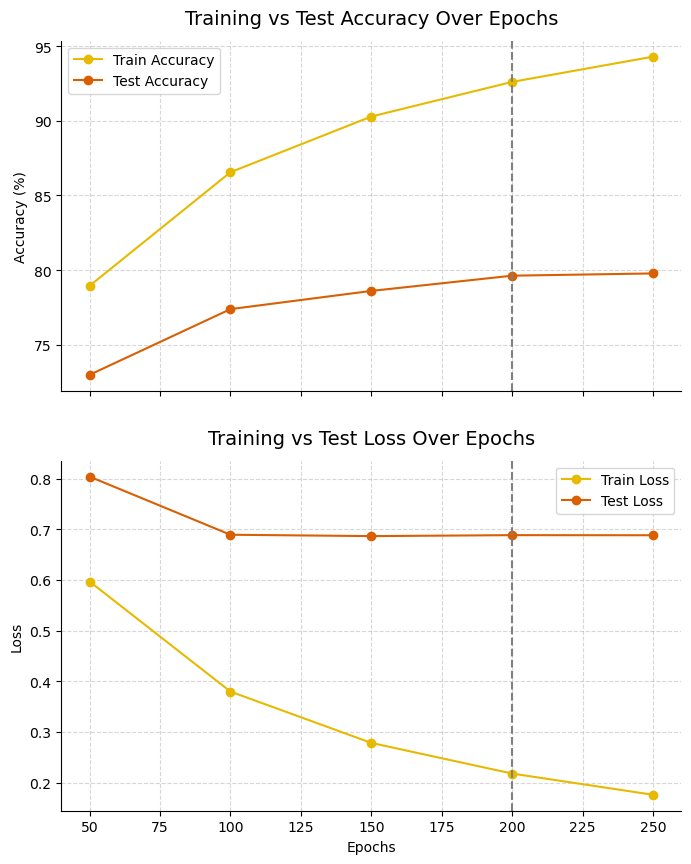

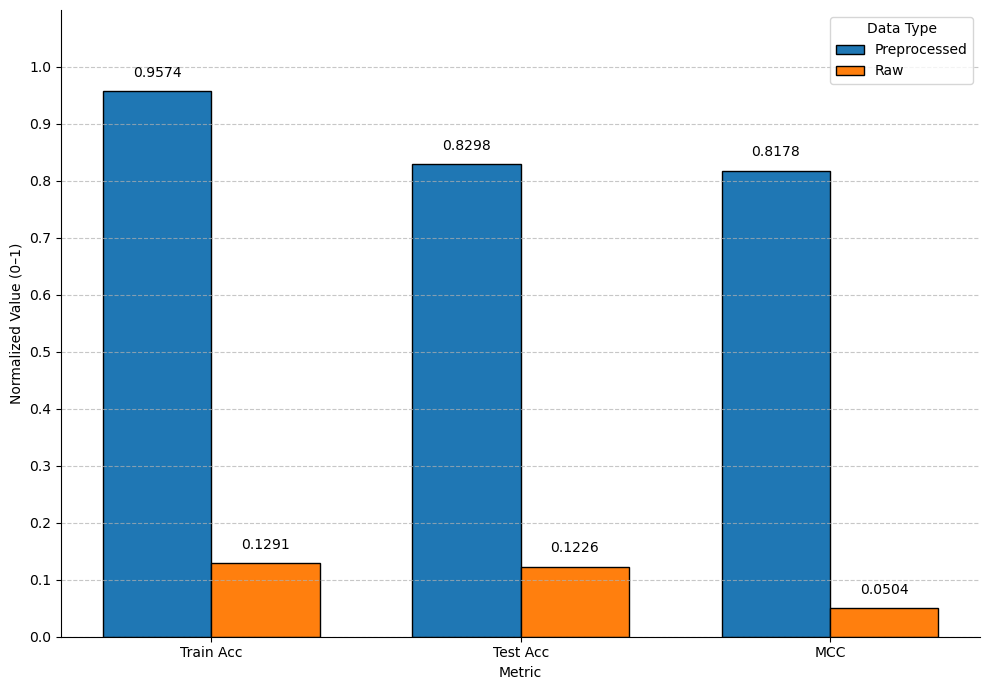

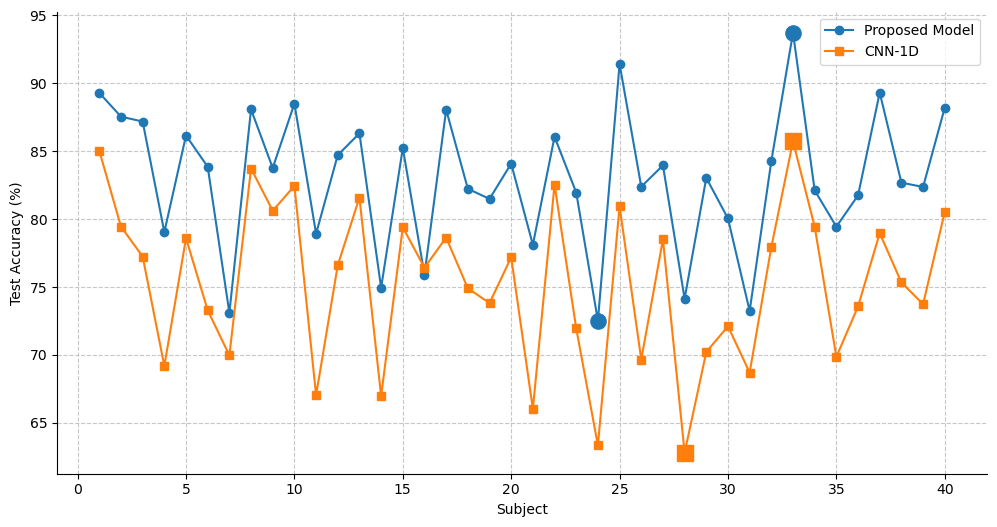

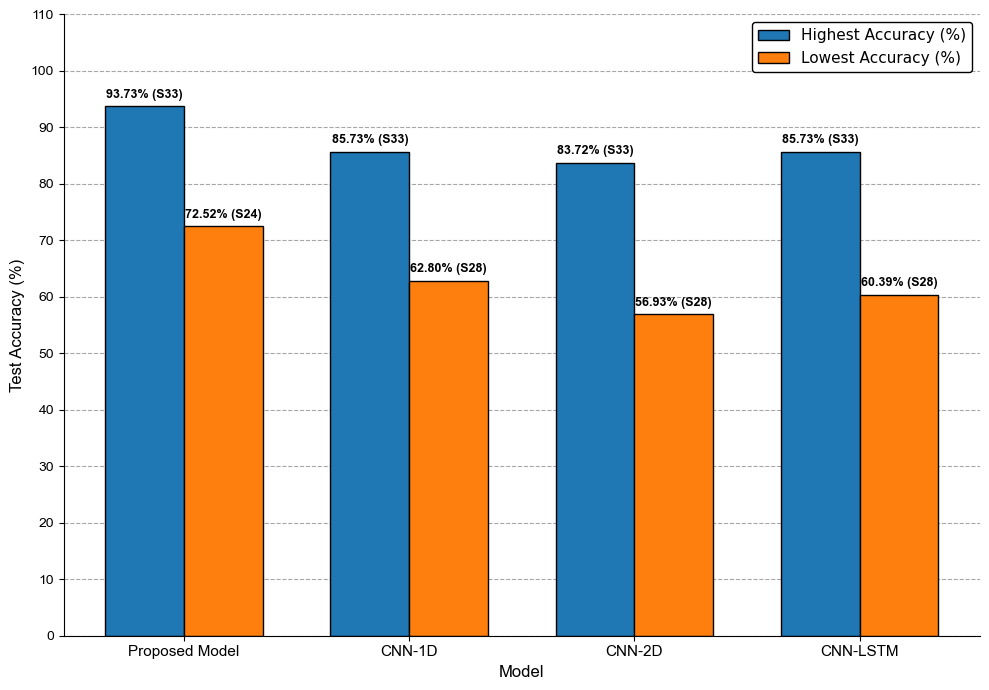

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
timeline_data = {
    'Stage': ['Epochs','LR/BS','Heads/Head Size','MLP/FF Dims','Dropout'],
    'Test Acc': [79.63,82.21,82.50,82.70,82.98]
}
td = pd.DataFrame(timeline_data)

# 2) Make a wider figure
fig, ax = plt.subplots(figsize=(10,6), dpi=100)

# 3) Plot
ax.plot(td['Stage'], td['Test Acc'], marker='o', color='#d95f02', label='Test Acc')
ax.set_xlabel('Experiment Stage', fontsize=14)
ax.set_ylabel('Test Accuracy (%)', fontsize=14)
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)
ax.grid(True, linestyle='--', alpha=0.5)
ax.legend()

# 4) Layout
fig.tight_layout()
plt.show()

















import matplotlib.pyplot as plt
import pandas as pd

# Data setup
data = {
    'Epochs': [50, 100, 150, 200, 250],
    'Train Accuracy (%)': [78.95, 86.56, 90.29, 92.61, 94.30],
    'Test Accuracy (%)': [72.99, 77.39, 78.61, 79.63, 79.78],
    'Train Loss': [0.5971, 0.3796, 0.2782, 0.2176, 0.1757],
    'Test Loss': [0.8043, 0.6895, 0.6868, 0.6887, 0.6885],
}
df = pd.DataFrame(data)

# Create figure with 2 subplots (vertically stacked)
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(8, 10), sharex=True)

# --- Plot 1: Accuracy ---
ax1.plot(df['Epochs'], df['Train Accuracy (%)'], marker='o', color='#e7ba01', label='Train Accuracy')
ax1.plot(df['Epochs'], df['Test Accuracy (%)'], marker='o', color='#d95f02', label='Test Accuracy')
ax1.axvline(x=200, color='gray', linestyle='--')
ax1.spines['right'].set_visible(False)
ax1.spines['top'].set_visible(False)
ax1.set_title('Training vs Test Accuracy Over Epochs', fontsize=14, pad=12)
ax1.set_ylabel('Accuracy (%)')
ax1.legend()
ax1.grid(True, linestyle='--', alpha=0.5)

# --- Plot 2: Loss ---
ax2.plot(df['Epochs'], df['Train Loss'], marker='o', color='#e7ba01', label='Train Loss')
ax2.plot(df['Epochs'], df['Test Loss'], marker='o', color='#d95f02', label='Test Loss')
ax2.axvline(x=200, color='gray', linestyle='--')
ax2.spines['right'].set_visible(False)
ax2.spines['top'].set_visible(False)
ax2.set_title('Training vs Test Loss Over Epochs', fontsize=14, pad=12)
ax2.set_xlabel('Epochs')
ax2.set_ylabel('Loss')
ax2.legend()
ax2.grid(True, linestyle='--', alpha=0.5)



















import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Original data
raw_pre_df = pd.DataFrame({
    'Metric': ['Train Acc', 'Test Acc', 'MCC'],
    'Preprocessed': [95.74, 82.98, 0.8178],
    'Raw': [12.91, 12.26, 0.0504]
})

# Normalize only accuracy rows (first two rows)
df_norm = raw_pre_df.copy()
df_norm.loc[0:2, ['Preprocessed', 'Raw']] = df_norm.loc[0:2, ['Preprocessed', 'Raw']].copy()
df_norm.loc[0:1, ['Preprocessed', 'Raw']] /= 100  # Normalize only Train Acc and Test Acc

# Plot
x = np.arange(len(df_norm['Metric']))
bar_width = 0.35
colors = ['#1f77b4', '#ff7f0e']

plt.figure(figsize=(10, 7))
for i, col in enumerate(['Preprocessed', 'Raw']):
    values = df_norm[col]
    bars = plt.bar(x + (i - 0.5) * bar_width, values, width=bar_width,
                   color=colors[i], edgecolor='black', label=col)

    for j, bar in enumerate(bars):
        height = bar.get_height()
        # Show normalized value directly (no %)
        label = f'{height:.4f}'
        plt.text(bar.get_x() + bar.get_width() / 2, height + 0.02,
                 label, ha='center', va='bottom', fontsize=10)
plt.gca().spines['right'].set_visible(False)
plt.gca().spines['top'].set_visible(False)
plt.xlabel('Metric')
plt.ylabel('Normalized Value (0–1)')
plt.xticks(x, df_norm['Metric'])
plt.ylim(0, 1.1)
plt.yticks(np.arange(0, 1.1, 0.1))
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.legend(title='Data Type')
plt.tight_layout()
plt.show()












import matplotlib.pyplot as plt
import numpy as np

subjects = list(range(1, 41))
transformer_acc = [89.30, 87.55, 87.19, 79.05, 86.16, 83.86, 73.10, 88.08, 83.77, 88.51,
                  78.93, 84.72, 86.32, 74.95, 85.24, 75.91, 88.06, 82.24, 81.49, 84.09,
                  78.11, 86.07, 81.96, 72.52, 91.43, 82.39, 83.96, 74.14, 83.04, 80.05,
                  73.24, 84.28, 93.73, 82.12, 79.45, 81.75, 89.32, 82.69, 82.37, 88.21]
cnn1d_acc = [85.03, 79.45, 77.25, 69.19, 78.60, 73.29, 69.97, 83.73, 80.62, 82.45,
             67.03, 76.61, 81.59, 66.97, 79.40, 76.43, 78.64, 74.91, 73.82, 77.19,
             66.02, 82.54, 71.95, 63.34, 80.95, 69.66, 78.51, 62.80, 70.22, 72.11,
             68.70, 77.95, 85.73, 79.44, 69.86, 73.57, 78.97, 75.34, 73.74, 80.53]

fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(subjects, transformer_acc, label='Proposed Model', color='#1f77b4', marker='o')
ax.plot(subjects, cnn1d_acc, label='CNN-1D', color='#ff7f0e', marker='s')


# Find best and worst for Transformer
max_idx_t = np.argmax(transformer_acc)
min_idx_t = np.argmin(transformer_acc)
ax.scatter(subjects[max_idx_t], transformer_acc[max_idx_t], color='#1f77b4', s=120, marker='o', zorder=5)
ax.scatter(subjects[min_idx_t], transformer_acc[min_idx_t], color='#1f77b4', s=120, marker='o', zorder=5)


# Find best and worst for CNN-1D
max_idx_cnn = np.argmax(cnn1d_acc)
min_idx_cnn = np.argmin(cnn1d_acc)
ax.scatter(subjects[max_idx_cnn], cnn1d_acc[max_idx_cnn], color='#ff7f0e', s=120, marker='s', zorder=5)
ax.scatter(subjects[min_idx_cnn], cnn1d_acc[min_idx_cnn], color='#ff7f0e', s=120, marker='s', zorder=5)


ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.set_xlabel('Subject')
ax.set_ylabel('Test Accuracy (%)')
ax.legend()
ax.grid(True, linestyle='--', alpha=0.7)

plt.show()









import matplotlib.pyplot as plt
import numpy as np

# ---------------------------
# Data
# ---------------------------
models = ['Proposed Model', 'CNN-1D', 'CNN-2D', 'CNN-LSTM']
highest_acc = [93.73, 85.73, 83.72, 85.73]
lowest_acc = [72.52, 62.80, 56.93, 60.39]
highest_subjects = ['S33', 'S33', 'S33', 'S33']
lowest_subjects = ['S24', 'S28', 'S28', 'S28']

# ---------------------------
# Plotting
# ---------------------------
x = np.arange(len(models))
bar_width = 0.35
colors = ['#1f77b4', '#ff7f0e']

plt.figure(figsize=(10, 7))

# Plot bars
for i, (label, values, subjects) in enumerate(zip(
    ['Highest Accuracy (%)', 'Lowest Accuracy (%)'],
    [highest_acc, lowest_acc],
    [highest_subjects, lowest_subjects]
)):
    plt.bar(
        x + (i - 0.5) * bar_width,
        values,
        width=bar_width,
        color=colors[i],
        edgecolor='black',
        label=label
    )
    # Annotate with combined accuracy and subject
    for j, (val, subj) in enumerate(zip(values, subjects)):
        plt.text(
            x[j] + (i - 0.5) * bar_width,
            val + 1,
            f'{val:.2f}% ({subj})',
            ha='center',
            va='bottom',
            fontsize=9,
            fontfamily='Arial',
            fontweight='bold',
            color='black'
        )

# Grid and labels
plt.gca().set_axisbelow(True)
plt.grid(axis='y', linestyle='--', alpha=0.7, color='gray')
plt.xlabel('Model', fontsize=12, fontfamily='Arial')
plt.ylabel('Test Accuracy (%)', fontsize=12, fontfamily='Arial')
plt.xticks(x, models, fontsize=11, fontfamily='Arial')
plt.gca().spines['right'].set_visible(False)
plt.gca().spines['top'].set_visible(False)
plt.ylim(0, 110)  # Extended y-limit to accommodate labels
plt.yticks(np.arange(0, 111, 10), fontsize=10, fontfamily='Arial')
plt.legend(fontsize=11, frameon=True, edgecolor='black', framealpha=1)

plt.tight_layout()
plt.show()






import matplotlib.pyplot as plt

# Task definitions (in milliseconds)
tasks = [
    'Data Window Duration', 
    'Per-window Avg. Test Time', 
    'Safety Margin', 
    'Per-window Avg. Train Time'
]
durations = [150, 1.862, 100 - 1.862, 46.484]

# Create figure and axis
fig, ax = plt.subplots(figsize=(8, 3), dpi=100)

# Plot horizontal bars with explicit colors and consistent height
colors = ['#1f77b4', '#EF5350','#999999','#FFA726' ]
bar_height = 0.6
ax.barh(tasks, durations, color=colors, height=bar_height)

# Add a vertical dashed line at the 100 ms stride interval
ax.axvline(x=100, color='black', linestyle='--', linewidth=1)
ax.text(102, 2, 'Stride Interval\n(100 ms)', va='center', fontsize=10)
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)
# Add light gridlines for x-axis
ax.grid(True, linestyle='--', linewidth=0.5, alpha=0.7)

# Customize plot
ax.set_xlabel('Time (ms)')
ax.set_xlim(0, 160)
ax.invert_yaxis()  # Highest bar at top

plt.tight_layout()
plt.show()












